# QAOA Model Evaluation — 10 Nodes
Compares GPT vs LLaMA architectures and Feather / NetLSD / GNN embeddings
against the ADAPT baseline on 10-node graphs.

In [1]:
# ------------------------
# IMPORTS
# ------------------------

import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

from src.model_interface import QAOA_GPT
from src.adapt_utils import compute_metrics_per_graph

from src.utils import (
    attach_resolved_names,
    load_and_aggregate_adapt,
    build_results_df,
    build_final_df,
    build_summary_df,
)

pd.set_option("display.max_columns", None)

In [2]:
# ------------------------
# CONFIG
# ------------------------

SEED            = 1337
data_input_path = "./ADAPT.jl_results/test/10_nodes"
N_SAMPLES       = 5
MAX_TOKENS      = 150

# Two architectures x three embeddings = 6 models.
# No 'name' key -> auto-extracted as "<Arch>-<Method>".
MODEL_CONFIGS = [
    dict(
        ckpt     = "nanoGPT/out-10_nodes_feather/gpt_ckpt_3500_feather_ar_0_96305__er_0_0.pt",
        data_dir = "nanoGPT/data/10_nodes_feather",
    ),
    dict(
        ckpt     = "nanoGPT/out-10_nodes_netlsd/gpt_ckpt_3500_netlsd_ar_0_95477__er_0_0.pt",
        data_dir = "nanoGPT/data/10_nodes_netlsd",
    ),
    dict(
        ckpt     = "nanoGPT/out-10_nodes_gnn/gpt_ckpt_4500_gnn_ar_0_96316__er_0_0.pt",
        data_dir = "nanoGPT/data/10_nodes_gnn",
    ),
    dict(
        ckpt     = "nanoGPT/out-10_nodes_feather/llama_ckpt_6500_feather_ar_0_93013__er_0_12.pt",
        data_dir = "nanoGPT/data/10_nodes_feather",
    ),
    dict(
        ckpt     = "nanoGPT/out-10_nodes_netlsd/llama_ckpt_6000_netlsd_ar_0_9436__er_0_026.pt",
        data_dir = "nanoGPT/data/10_nodes_netlsd",
    ),
    dict(
        ckpt     = "nanoGPT/out-10_nodes_gnn/llama_ckpt_5500_gnn_ar_0_924__er_0_006.pt",
        data_dir = "nanoGPT/data/10_nodes_gnn",
    ),
]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Attach resolved_name / arch / method to every config
MODEL_CONFIGS = attach_resolved_names(MODEL_CONFIGS)
print(f"MODEL_CONFIGS: {MODEL_CONFIGS}")

Resolved model names:
  NanoGPT-Feather  (arch=NanoGPT, method=Feather)
  NanoGPT-NetLSD  (arch=NanoGPT, method=NetLSD)
  NanoGPT-GNN  (arch=NanoGPT, method=GNN)
  LLaMA-Feather  (arch=LLaMA, method=Feather)
  LLaMA-NetLSD  (arch=LLaMA, method=NetLSD)
  LLaMA-GNN  (arch=LLaMA, method=GNN)
MODEL_CONFIGS: [{'ckpt': 'nanoGPT/out-10_nodes_feather/gpt_ckpt_3500_feather_ar_0_96305__er_0_0.pt', 'data_dir': 'nanoGPT/data/10_nodes_feather', 'resolved_name': 'NanoGPT-Feather', 'arch': 'NanoGPT', 'method': 'Feather'}, {'ckpt': 'nanoGPT/out-10_nodes_netlsd/gpt_ckpt_3500_netlsd_ar_0_95477__er_0_0.pt', 'data_dir': 'nanoGPT/data/10_nodes_netlsd', 'resolved_name': 'NanoGPT-NetLSD', 'arch': 'NanoGPT', 'method': 'NetLSD'}, {'ckpt': 'nanoGPT/out-10_nodes_gnn/gpt_ckpt_4500_gnn_ar_0_96316__er_0_0.pt', 'data_dir': 'nanoGPT/data/10_nodes_gnn', 'resolved_name': 'NanoGPT-GNN', 'arch': 'NanoGPT', 'method': 'GNN'}, {'ckpt': 'nanoGPT/out-10_nodes_feather/llama_ckpt_6500_feather_ar_0_93013__er_0_12.pt', 'data_dir'

In [3]:
# ------------------------
# LOAD ADAPT & GRAPHS
# ------------------------

adapt_df, adapt_agg, graphs_unique, meta_df = load_and_aggregate_adapt(data_input_path)

Reading ADAPT.jl results from:
	 /home/mrzaizai2k/code_bao/ADAPT_GPT/ADAPT.jl_results/test/10_nodes


Opening ADAPT results (10_nodes): 100%|██████████| 1/1 [00:00<00:00, 24.11it/s]


df_list len: 1


Opening graphs (10_nodes): 100%|██████████| 1/1 [00:00<00:00, 498.14it/s]

df_list len: 1
Graphs count:
g_method
erdos_renyi    100
Name: count, dtype: int64
Aggregating results...
Total ADAPT rows      : 146
Unique graphs         : 100
Runs per graph (mean) : 1.46

Aggregated ADAPT shape : (100, 8)
Graphs fed to model    : 100


In [4]:
adapt_agg.head()

,graph_num,graph_name,adapt_ar_mean,adapt_ar_best,adapt_ar_std,adapt_layers_mean,adapt_layers_best,adapt_n_runs
0,1,Graph_1,0.971994,0.971994,0.0,11.0,11,1
1,2,Graph_2,0.987440,0.987440,0.0,14.0,14,1
2,3,Graph_3,0.976510,0.976510,0.0,7.0,7,1
3,4,Graph_4,0.971611,0.971611,0.0,8.0,8,1
4,5,Graph_5,0.977373,0.977373,0.0,8.0,8,1


In [5]:
# ------------------------
# MODEL UTILS (local)
# ------------------------

def load_model(cfg):
    return QAOA_GPT(
        model_ckpt=cfg["ckpt"],
        data_dir=cfg["data_dir"],
        temp_folder="temp_data",
    )


def run_model(qaoa, graphs):
    df_model = qaoa.generate_circ_from_nx(
        graphs,
        num_samples=N_SAMPLES,
        max_new_tokens=MAX_TOKENS,
        temperature=0.1,
        top_k=200,
    )
    return qaoa.eval_circ_df_jl(df_model)

In [ ]:
# ------------------------
# MODEL UTILS
# ------------------------

all_results = []

for cfg in MODEL_CONFIGS:
    model_name = cfg["resolved_name"]
    print(f"\nRunning {model_name} ...")

    model = QAOA_GPT(
        model_ckpt=cfg["ckpt"],
        data_dir=cfg["data_dir"],
    )
    df_model = model.generate_circ_from_nx(
        graphs_unique,
        num_samples=N_SAMPLES,
        max_new_tokens=MAX_TOKENS,
        temperature=0.1,
        top_k=200,
    )

    df_eval = model.eval_circ_df_jl(df_model)

    ar, layers, error_rate = compute_metrics_per_graph(df_eval)

    all_results.append(build_results_df(meta_df, cfg, ar, layers, error_rate))

model_results_df = pd.concat(all_results, ignore_index=True)


Running NanoGPT-Feather ...

Model type: gpt
Pool type: qaoa_double_pool
Embedding method: feather
Number of nodes: 10
Initiating nanoGPT model with padding support
number of parameters: 11.68M


Preparing graphs...:   0%|          | 0/100 [00:00<?, ?it/s]

Restricted license - for non-production use only - expires 2027-11-29


Preparing graphs...: 100%|██████████| 100/100 [00:00<00:00, 270.28it/s]


Performing feather embedding


...

Performing gnn embedding
GNN model initialized on device: cuda


GNN: 100%|██████████| 100/100 [00:00<00:00, 258.99it/s]


GNN shape: (100, 500)


Inference. Current batch: n_edges: 13, n_graphs: 1: 100%|██████████| 31/31 [00:34<00:00,  1.12s/it]



===== DEBUG INFO =====
CWD: /home/mrzaizai2k/code_bao/ADAPT_GPT
Command:
/opt/julia-1.12.1/bin/julia -t 4 --project=/home/mrzaizai2k/code_bao/ADAPT_GPT/ADAPT.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/adapt_gpt_eval_energy.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-04-04__17_46_00_df.json /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-04-04__17_46_00_df_jl.json 10 qaoa_double_pool


Julia return code: 0
  AR: 0.8112 | layers: 12.23 | error_rate: 2.00%


In [7]:
model_results_df.head()

,graph_name,graph_num,model,arch,method,model_ar,model_layers,model_error_rate
0,Graph_1,1,NanoGPT-Feather,NanoGPT,Feather,0.963287,9.8,0.0
1,Graph_2,2,NanoGPT-Feather,NanoGPT,Feather,0.958512,9.0,0.0
2,Graph_3,3,NanoGPT-Feather,NanoGPT,Feather,0.970816,9.2,0.0
3,Graph_4,4,NanoGPT-Feather,NanoGPT,Feather,0.968325,8.4,0.0
4,Graph_5,5,NanoGPT-Feather,NanoGPT,Feather,0.974922,8.0,0.0


In [8]:
# ------------------------
# MERGE & SUMMARY
# ------------------------

final_df   = build_final_df(adapt_agg, model_results_df)
summary_df = build_summary_df(final_df)

print(summary_df.to_string(index=False))

          model    arch  method  adapt_ar_mean  adapt_ar_best  model_ar  adapt_layers  model_error_rate  model_layers ar_diff_vs_mean ar_diff_vs_best  n_graphs
  LLaMA-Feather   LLaMA Feather       0.972405       0.978554  0.927998     13.371667             0.072        11.982       -0.044419       -0.050524       100
      LLaMA-GNN   LLaMA     GNN       0.972405       0.978554   0.81122     13.371667             0.020        12.230        -0.16118       -0.167326       100
   LLaMA-NetLSD   LLaMA  NetLSD       0.972405       0.978554  0.944997     13.371667             0.010        10.572       -0.027409       -0.033557       100
NanoGPT-Feather NanoGPT Feather       0.972405       0.978554  0.962361     13.371667             0.000         8.790       -0.010044       -0.016193       100
    NanoGPT-GNN NanoGPT     GNN       0.972405       0.978554   0.93654     13.371667             0.388        20.964        -0.03695       -0.042918       100
 NanoGPT-NetLSD NanoGPT  NetLSD       0.

In [9]:
final_df.head(10)

,graph_num,graph_name,adapt_ar_mean,adapt_ar_best,adapt_ar_std,adapt_layers_mean,adapt_layers_best,adapt_n_runs,model,arch,method,model_ar,model_layers,model_error_rate,ar_diff_vs_mean,ar_diff_vs_best,layer_diff
0,1,Graph_1,0.971994,0.971994,0.0,11.0,11,1,NanoGPT-Feather,NanoGPT,Feather,0.963287,9.8,0.0,-0.008707,-0.008707,-1.2
1,1,Graph_1,0.971994,0.971994,0.0,11.0,11,1,NanoGPT-NetLSD,NanoGPT,NetLSD,0.943684,9.6,0.0,-0.028311,-0.028311,-1.4
2,1,Graph_1,0.971994,0.971994,0.0,11.0,11,1,NanoGPT-GNN,NanoGPT,GNN,0.956524,21.0,0.0,-0.01547,-0.01547,10.0
3,1,Graph_1,0.971994,0.971994,0.0,11.0,11,1,LLaMA-Feather,LLaMA,Feather,0.95136,10.4,0.0,-0.020634,-0.020634,-0.6
4,1,Graph_1,0.971994,0.971994,0.0,11.0,11,1,LLaMA-NetLSD,LLaMA,NetLSD,0.951821,11.2,0.0,-0.020173,-0.020173,0.2
5,1,Graph_1,0.971994,0.971994,0.0,11.0,11,1,LLaMA-GNN,LLaMA,GNN,0.469254,11.4,0.0,-0.502741,-0.502741,0.4
6,2,Graph_2,0.987440,0.987440,0.0,14.0,14,1,NanoGPT-Feather,NanoGPT,Feather,0.958512,9.0,0.0,-0.028928,-0.028928,-5.0
7,2,Graph_2,0.987440,0.987440,0.0,14.0,14,1,NanoGPT-NetLSD,NanoGPT,NetLSD,0.953954,9.2,0.0,-0.033486,-0.033486,-4.8
8,2,Graph_2,0.987440,0.987440,0.0,14.0,14,1,LLaMA-Feather,LLaMA,Feather,0.876607,17.2,0.0,-0.110833,-0.110833,3.2
9,2,Graph_2,0.987440,0.987440,0.0,14.0,14,1,NanoGPT-GNN,NanoGPT,GNN,NaN,31.4,1.0,NaN,NaN,17.4


In [10]:
# ============================================================
# PLOT HELPERS
# ============================================================

ADAPT_PALETTE = {"mean": "#4C72B0", "best": "#55A868", "std_fill": "#4C72B0"}

# Fixed palettes so arch / method colors stay consistent across all plots
ARCH_COLORS   = {"GPT": "#C44E52", "LLaMA": "#4878CF"}
METHOD_COLORS = {"Feather": "#DD8452", "NetLSD": "#8172B2", "GNN": "#55A868"}

MODEL_MARKERS = {"GPT": "o", "LLaMA": "s"}


def _model_colors(models):
    """Fallback per-model color assignment (used in plots not split by arch/method)."""
    palette = ["#C44E52", "#DD8452", "#8172B2", "#937860", "#DA8BC3", "#8C8C8C",
               "#4878CF", "#6ACC65", "#B47CC7", "#C4AD66"]
    return {m: palette[i % len(palette)] for i, m in enumerate(models)}

In [11]:
# ============================================================
# SECTION 1 — Overall model comparison (same as 9-node report)
# ============================================================

def plot_ar_bar(summary_df):
    """Bar chart: average AR — ADAPT mean/best vs each model."""
    models = summary_df["model"].tolist()
    mc     = _model_colors(models)
    n      = len(models)
    x      = np.arange(n)
    w      = 0.22

    fig, ax = plt.subplots(figsize=(max(6, n * 2), 5))
    ax.bar(x - w, summary_df["adapt_ar_mean"], width=w, label="ADAPT (mean)",
           color=ADAPT_PALETTE["mean"])
    ax.bar(x,     summary_df["adapt_ar_best"], width=w, label="ADAPT (best)",
           color=ADAPT_PALETTE["best"])
    for i, (_, row) in enumerate(summary_df.iterrows()):
        ax.bar(x[i] + w, row["model_ar"], width=w, label=row["model"],
               color=mc[row["model"]])

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha="right")
    ax.set_ylabel("Approximation Ratio")
    ax.set_title("Average AR: ADAPT vs All Models")
    ax.set_ylim(
        min(summary_df["adapt_ar_mean"].min(), summary_df["model_ar"].min()) - 0.02,
        1.01,
    )
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.4)
    fig.tight_layout()
    plt.show()


def plot_layers_bar(summary_df):
    """Bar chart: average layers — ADAPT mean vs each model."""
    models = summary_df["model"].tolist()
    mc     = _model_colors(models)
    n      = len(models)
    x      = np.arange(n)
    w      = 0.25

    fig, ax = plt.subplots(figsize=(max(6, n * 2), 5))
    ax.bar(x - w / 2, summary_df["adapt_layers"], width=w,
           label="ADAPT (mean)", color=ADAPT_PALETTE["mean"])
    for i, (_, row) in enumerate(summary_df.iterrows()):
        ax.bar(x[i] + w / 2, row["model_layers"], width=w,
               label=row["model"], color=mc[row["model"]])

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha="right")
    ax.set_ylabel("Layers")
    ax.set_title("Average QAOA Layers: ADAPT vs All Models")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.4)
    fig.tight_layout()
    plt.show()


def plot_error_rate_bar(summary_df):
    """Bar chart: model error rate per model."""
    models = summary_df["model"].tolist()
    mc     = _model_colors(models)
    n      = len(models)
    x      = np.arange(n)

    fig, ax = plt.subplots(figsize=(max(6, n * 2), 5))
    for i, (_, row) in enumerate(summary_df.iterrows()):
        ax.bar(x[i], row["model_error_rate"], width=0.4,
               label=row["model"], color=mc[row["model"]])

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha="right")
    ax.set_ylabel("Error Rate")
    ax.set_title("Circuit Error Rate (fraction of invalid outputs)")
    ax.set_ylim(0, min(1.0, summary_df["model_error_rate"].max() + 0.05))
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.4)
    fig.tight_layout()
    plt.show()


def plot_ar_vs_layers_scatter(final_df):
    """Scatter: AR vs Layers — ADAPT + all models, colored by arch."""
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.scatter(final_df["adapt_layers_mean"], final_df["adapt_ar_mean"],
               label="ADAPT (mean)", alpha=0.5, color=ADAPT_PALETTE["mean"], zorder=2)
    ax.scatter(final_df["adapt_layers_best"], final_df["adapt_ar_best"],
               label="ADAPT (best)", alpha=0.5, color=ADAPT_PALETTE["best"],
               marker="^", zorder=2)

    for model, grp in final_df.groupby("model"):
        arch   = grp["arch"].iloc[0]
        color  = ARCH_COLORS.get(arch, "#8C8C8C")
        marker = MODEL_MARKERS.get(arch, "D")
        ax.scatter(grp["model_layers"], grp["model_ar"],
                   label=model, alpha=0.65, color=color, marker=marker, zorder=3)

    ax.set_xlabel("Layers")
    ax.set_ylabel("Approximation Ratio")
    ax.set_title("AR vs Layers Trade-off (marker shape = arch)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.4)
    fig.tight_layout()
    plt.show()


def plot_per_graph_ar(final_df):
    """Line plot: per-graph AR for ADAPT + all models, x-axis = graph_num."""
    models      = final_df["model"].unique().tolist()
    mc          = _model_colors(models)
    graph_order = sorted(final_df["graph_num"].unique())

    adapt_base = (
        final_df[final_df["model"] == models[0]]
        .set_index("graph_num")
        .reindex(graph_order)
    )

    fig, ax = plt.subplots(figsize=(max(10, len(graph_order) // 5), 5))

    ax.plot(graph_order, adapt_base["adapt_ar_mean"], label="ADAPT (mean)",
            color=ADAPT_PALETTE["mean"], linewidth=1.5)
    ax.fill_between(
        graph_order,
        adapt_base["adapt_ar_mean"] - adapt_base["adapt_ar_std"],
        adapt_base["adapt_ar_mean"] + adapt_base["adapt_ar_std"],
        alpha=0.12, color=ADAPT_PALETTE["mean"],
    )
    ax.plot(graph_order, adapt_base["adapt_ar_best"], label="ADAPT (best)",
            color=ADAPT_PALETTE["best"], linestyle="--", linewidth=1.2, alpha=0.75)

    for model, grp in final_df.groupby("model"):
        grp_ordered = grp.set_index("graph_num").reindex(graph_order)
        ax.plot(graph_order, grp_ordered["model_ar"],
                label=model, color=mc[model], linewidth=1.5)

    ax.set_xlabel("Graph number")
    ax.set_ylabel("Approximation Ratio")
    ax.set_title("Per-graph AR  (shaded = ADAPT ± 1 std)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.4)
    fig.tight_layout()
    plt.show()


def plot_ar_gap_hist(final_df):
    """Histogram: AR gap (model - ADAPT mean) per model."""
    models = final_df["model"].unique().tolist()
    mc     = _model_colors(models)

    fig, axes = plt.subplots(
        1, len(models),
        figsize=(max(6, 5 * len(models)), 4),
        sharey=True,
    )
    if len(models) == 1:
        axes = [axes]

    for ax, model in zip(axes, models):
        grp   = final_df[final_df["model"] == model]
        diffs = grp["ar_diff_vs_mean"]

        ax.hist(diffs, bins=20, color=mc[model], edgecolor="white", alpha=0.85)
        ax.axvline(0, color="black", linewidth=1.2, linestyle="--", label="Parity")
        ax.axvline(diffs.mean(), color="gold", linewidth=1.5,
                   label=f"Mean {diffs.mean():+.4f}")
        ax.set_title(f"{model}\nAR Gap")
        ax.set_xlabel("Model AR - ADAPT mean AR")
        ax.set_ylabel("Count" if ax == axes[0] else "")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.4)

    fig.suptitle("AR Gap: positive = model beats ADAPT mean", fontsize=11)
    fig.tight_layout()
    plt.show()

In [12]:
# ============================================================
# SECTION 2 — Embedding comparison (Feather vs NetLSD vs GNN)
# ============================================================

def plot_ar_by_method(summary_df):
    """
    Grouped bar chart: AR per embedding method.
    Each method has two bars — one per architecture.
    """
    methods = summary_df["method"].unique().tolist()
    archs   = summary_df["arch"].unique().tolist()
    n       = len(methods)
    x       = np.arange(n)
    w       = 0.3

    fig, ax = plt.subplots(figsize=(max(6, n * 2.5), 5))

    offsets = np.linspace(-(len(archs) - 1) / 2, (len(archs) - 1) / 2, len(archs)) * w
    for offset, arch in zip(offsets, archs):
        vals = [
            summary_df.loc[
                (summary_df["method"] == m) & (summary_df["arch"] == arch), "model_ar"
            ].mean()
            for m in methods
        ]
        ax.bar(x + offset, vals, width=w, label=arch,
               color=ARCH_COLORS.get(arch, "#8C8C8C"), alpha=0.85)

    # ADAPT mean reference line
    adapt_mean = summary_df["adapt_ar_mean"].mean()
    ax.axhline(adapt_mean, color=ADAPT_PALETTE["mean"], linestyle="--",
               linewidth=1.4, label=f"ADAPT mean ({adapt_mean:.4f})")

    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.set_ylabel("Approximation Ratio")
    ax.set_title("AR by Embedding Method (bars = architecture)")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.4)
    fig.tight_layout()
    plt.show()


def plot_error_rate_by_method(summary_df):
    """
    Grouped bar chart: error rate per embedding method, split by architecture.
    """
    methods = summary_df["method"].unique().tolist()
    archs   = summary_df["arch"].unique().tolist()
    n       = len(methods)
    x       = np.arange(n)
    w       = 0.3

    fig, ax = plt.subplots(figsize=(max(6, n * 2.5), 5))

    offsets = np.linspace(-(len(archs) - 1) / 2, (len(archs) - 1) / 2, len(archs)) * w
    for offset, arch in zip(offsets, archs):
        vals = [
            summary_df.loc[
                (summary_df["method"] == m) & (summary_df["arch"] == arch),
                "model_error_rate",
            ].mean()
            for m in methods
        ]
        ax.bar(x + offset, vals, width=w, label=arch,
               color=ARCH_COLORS.get(arch, "#8C8C8C"), alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.set_ylabel("Error Rate")
    ax.set_title("Error Rate by Embedding Method (bars = architecture)")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.4)
    fig.tight_layout()
    plt.show()


def plot_layers_by_method(summary_df):
    """
    Grouped bar chart: average layers per embedding method, split by architecture.
    Includes ADAPT mean as a reference line.
    """
    methods = summary_df["method"].unique().tolist()
    archs   = summary_df["arch"].unique().tolist()
    n       = len(methods)
    x       = np.arange(n)
    w       = 0.3

    fig, ax = plt.subplots(figsize=(max(6, n * 2.5), 5))

    offsets = np.linspace(-(len(archs) - 1) / 2, (len(archs) - 1) / 2, len(archs)) * w
    for offset, arch in zip(offsets, archs):
        vals = [
            summary_df.loc[
                (summary_df["method"] == m) & (summary_df["arch"] == arch),
                "model_layers",
            ].mean()
            for m in methods
        ]
        ax.bar(x + offset, vals, width=w, label=arch,
               color=ARCH_COLORS.get(arch, "#8C8C8C"), alpha=0.85)

    adapt_layers = summary_df["adapt_layers"].mean()
    ax.axhline(adapt_layers, color=ADAPT_PALETTE["mean"], linestyle="--",
               linewidth=1.4, label=f"ADAPT mean ({adapt_layers:.2f})")

    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.set_ylabel("Layers")
    ax.set_title("Layers by Embedding Method (bars = architecture)")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.4)
    fig.tight_layout()
    plt.show()


def plot_per_graph_ar_by_method(final_df):
    """
    One subplot per embedding method showing per-graph AR for each architecture.
    ADAPT mean is shown as a shared reference.
    """
    methods     = sorted(final_df["method"].unique())
    archs       = sorted(final_df["arch"].unique())
    graph_order = sorted(final_df["graph_num"].unique())

    adapt_base = (
        final_df[final_df["model"] == final_df["model"].iloc[0]]
        .set_index("graph_num")
        .reindex(graph_order)
    )

    fig, axes = plt.subplots(
        1, len(methods),
        figsize=(max(8, 7 * len(methods)), 5),
        sharey=True,
    )
    if len(methods) == 1:
        axes = [axes]

    for ax, method in zip(axes, methods):
        ax.plot(graph_order, adapt_base["adapt_ar_mean"],
                color=ADAPT_PALETTE["mean"], linewidth=1.3,
                linestyle="--", label="ADAPT mean", alpha=0.75)

        method_rows = final_df[final_df["method"] == method]
        for arch, grp in method_rows.groupby("arch"):
            grp_ordered = grp.set_index("graph_num").reindex(graph_order)
            ax.plot(graph_order, grp_ordered["model_ar"],
                    label=arch, color=ARCH_COLORS.get(arch, "#8C8C8C"), linewidth=1.5)

        ax.set_title(f"Embedding: {method}")
        ax.set_xlabel("Graph number")
        if ax == axes[0]:
            ax.set_ylabel("Approximation Ratio")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.4)

    fig.suptitle("Per-graph AR by Embedding Method", fontsize=12)
    fig.tight_layout()
    plt.show()

In [13]:
# ============================================================
# SECTION 3 — Architecture comparison (GPT vs LLaMA)
# ============================================================

def plot_ar_by_arch(summary_df):
    """
    Grouped bar chart: AR per architecture.
    Each arch has one bar per embedding method.
    """
    archs   = summary_df["arch"].unique().tolist()
    methods = summary_df["method"].unique().tolist()
    n       = len(archs)
    x       = np.arange(n)
    w       = 0.2

    fig, ax = plt.subplots(figsize=(max(6, n * 3), 5))

    offsets = np.linspace(-(len(methods) - 1) / 2, (len(methods) - 1) / 2, len(methods)) * w
    for offset, method in zip(offsets, methods):
        vals = [
            summary_df.loc[
                (summary_df["arch"] == a) & (summary_df["method"] == method), "model_ar"
            ].mean()
            for a in archs
        ]
        ax.bar(x + offset, vals, width=w, label=method,
               color=METHOD_COLORS.get(method, "#8C8C8C"), alpha=0.85)

    adapt_mean = summary_df["adapt_ar_mean"].mean()
    ax.axhline(adapt_mean, color=ADAPT_PALETTE["mean"], linestyle="--",
               linewidth=1.4, label=f"ADAPT mean ({adapt_mean:.4f})")

    ax.set_xticks(x)
    ax.set_xticklabels(archs)
    ax.set_ylabel("Approximation Ratio")
    ax.set_title("AR by Architecture (bars = embedding method)")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.4)
    fig.tight_layout()
    plt.show()


def plot_error_rate_by_arch(summary_df):
    """
    Grouped bar chart: error rate per architecture, split by embedding method.
    """
    archs   = summary_df["arch"].unique().tolist()
    methods = summary_df["method"].unique().tolist()
    n       = len(archs)
    x       = np.arange(n)
    w       = 0.2

    fig, ax = plt.subplots(figsize=(max(6, n * 3), 5))

    offsets = np.linspace(-(len(methods) - 1) / 2, (len(methods) - 1) / 2, len(methods)) * w
    for offset, method in zip(offsets, methods):
        vals = [
            summary_df.loc[
                (summary_df["arch"] == a) & (summary_df["method"] == method),
                "model_error_rate",
            ].mean()
            for a in archs
        ]
        ax.bar(x + offset, vals, width=w, label=method,
               color=METHOD_COLORS.get(method, "#8C8C8C"), alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(archs)
    ax.set_ylabel("Error Rate")
    ax.set_title("Error Rate by Architecture (bars = embedding method)")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.4)
    fig.tight_layout()
    plt.show()


def plot_arch_ar_distribution(final_df):
    """
    Box plot: distribution of per-graph AR for each architecture across all methods.
    Overlaid with ADAPT mean as a reference line.
    """
    archs = sorted(final_df["arch"].unique())
    data  = [final_df.loc[final_df["arch"] == a, "model_ar"].dropna() for a in archs]

    fig, ax = plt.subplots(figsize=(max(5, len(archs) * 2), 5))
    bp = ax.boxplot(data, labels=archs, patch_artist=True, notch=False)

    for patch, arch in zip(bp["boxes"], archs):
        patch.set_facecolor(ARCH_COLORS.get(arch, "#8C8C8C"))
        patch.set_alpha(0.7)

    adapt_mean = final_df["adapt_ar_mean"].mean()
    ax.axhline(adapt_mean, color=ADAPT_PALETTE["mean"], linestyle="--",
               linewidth=1.4, label=f"ADAPT mean ({adapt_mean:.4f})")

    ax.set_ylabel("Approximation Ratio")
    ax.set_title("AR Distribution by Architecture (all embeddings pooled)")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.4)
    fig.tight_layout()
    plt.show()


def plot_method_ar_distribution(final_df):
    """
    Box plot: distribution of per-graph AR for each embedding method across all archs.
    """
    methods = sorted(final_df["method"].unique())
    data    = [final_df.loc[final_df["method"] == m, "model_ar"].dropna() for m in methods]

    fig, ax = plt.subplots(figsize=(max(5, len(methods) * 2), 5))
    bp = ax.boxplot(data, labels=methods, patch_artist=True, notch=False)

    for patch, method in zip(bp["boxes"], methods):
        patch.set_facecolor(METHOD_COLORS.get(method, "#8C8C8C"))
        patch.set_alpha(0.7)

    adapt_mean = final_df["adapt_ar_mean"].mean()
    ax.axhline(adapt_mean, color=ADAPT_PALETTE["mean"], linestyle="--",
               linewidth=1.4, label=f"ADAPT mean ({adapt_mean:.4f})")

    ax.set_ylabel("Approximation Ratio")
    ax.set_title("AR Distribution by Embedding Method (all archs pooled)")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.4)
    fig.tight_layout()
    plt.show()

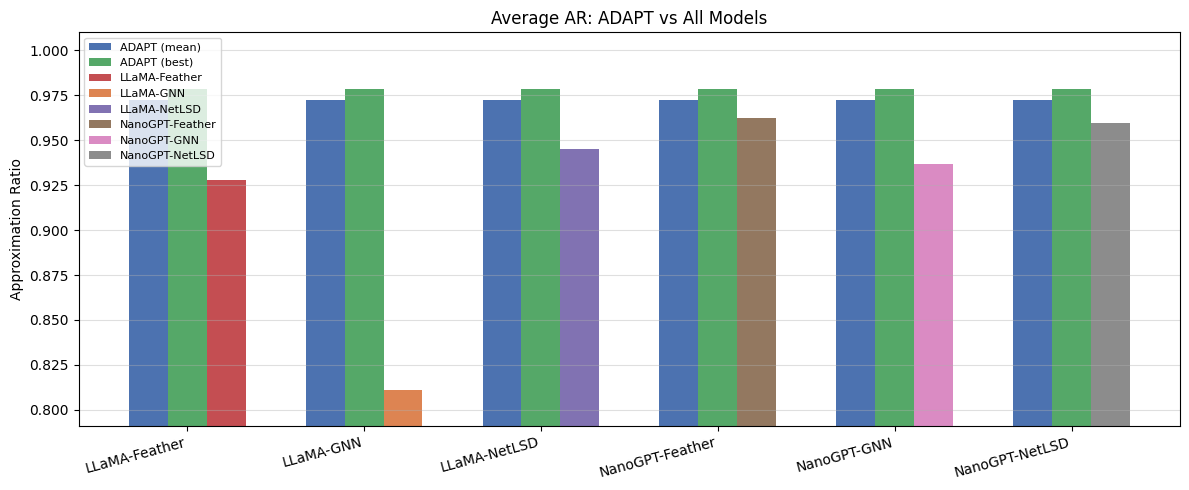

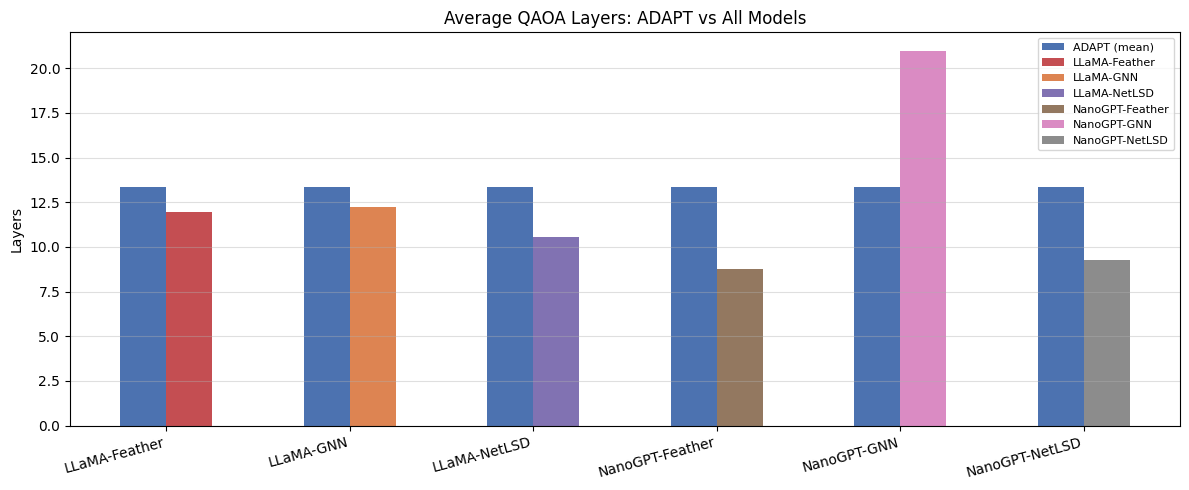

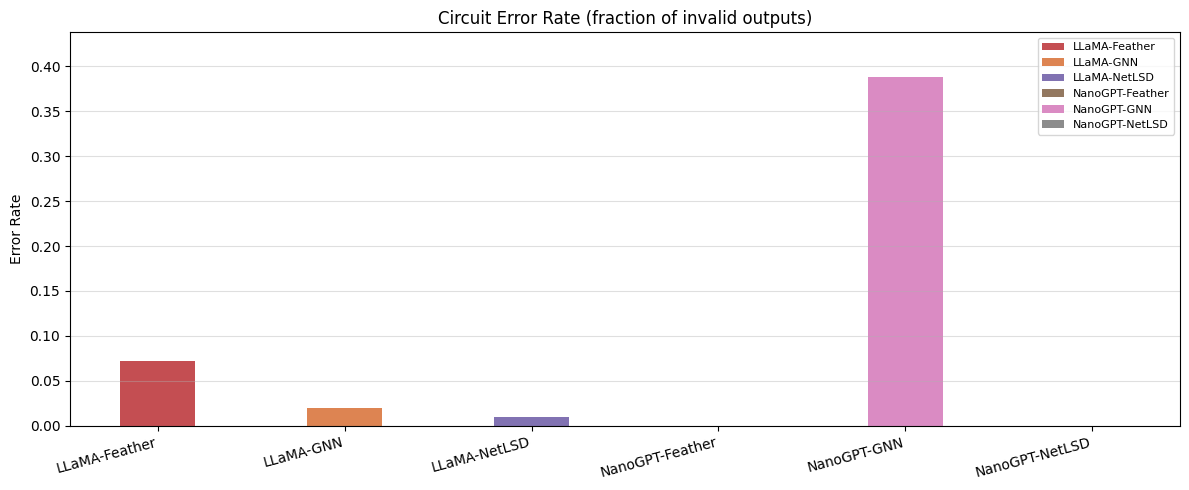

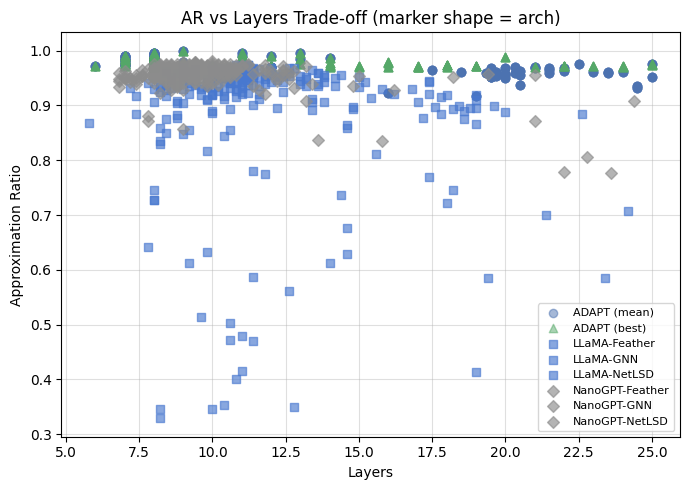

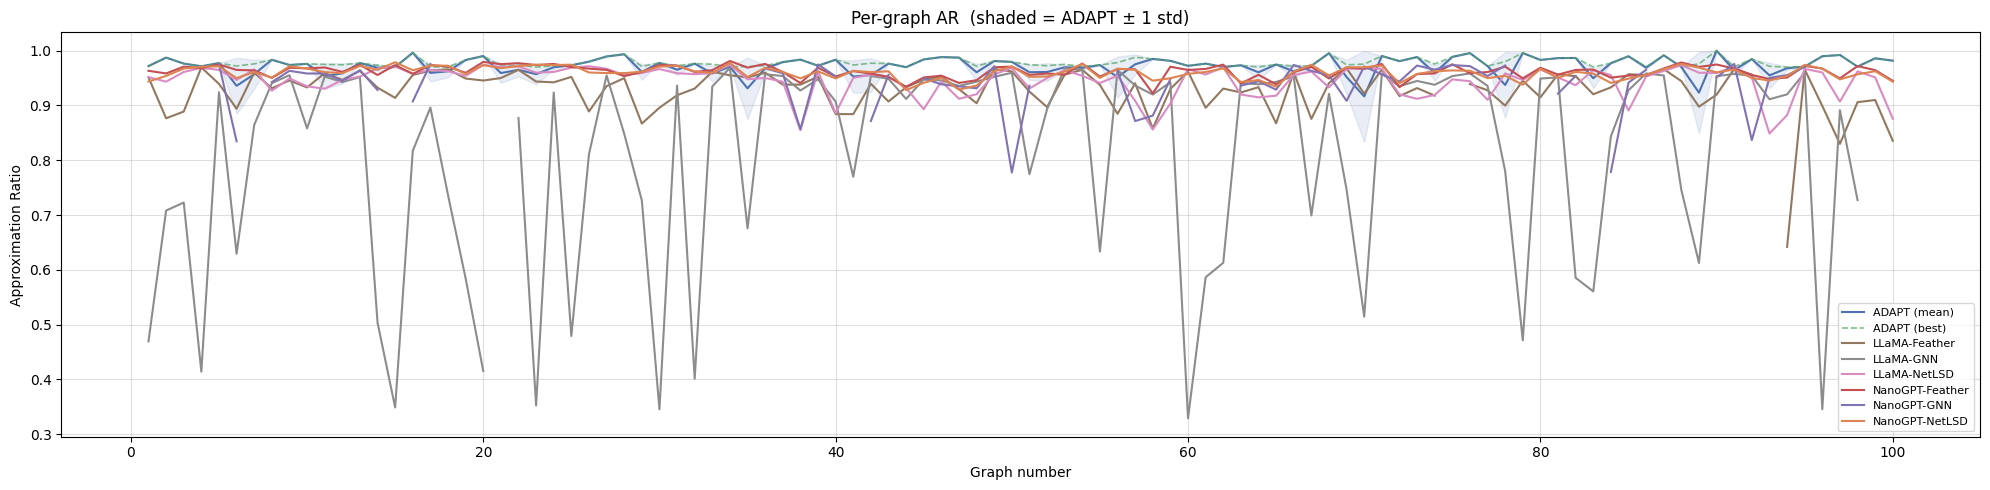

/home/mrzaizai2k/anaconda3/envs/adapt_gpt/lib/python3.10/site-packages/numpy/lib/_histograms_impl.py:841: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/home/mrzaizai2k/anaconda3/envs/adapt_gpt/lib/python3.10/site-packages/numpy/lib/_histograms_impl.py:842: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


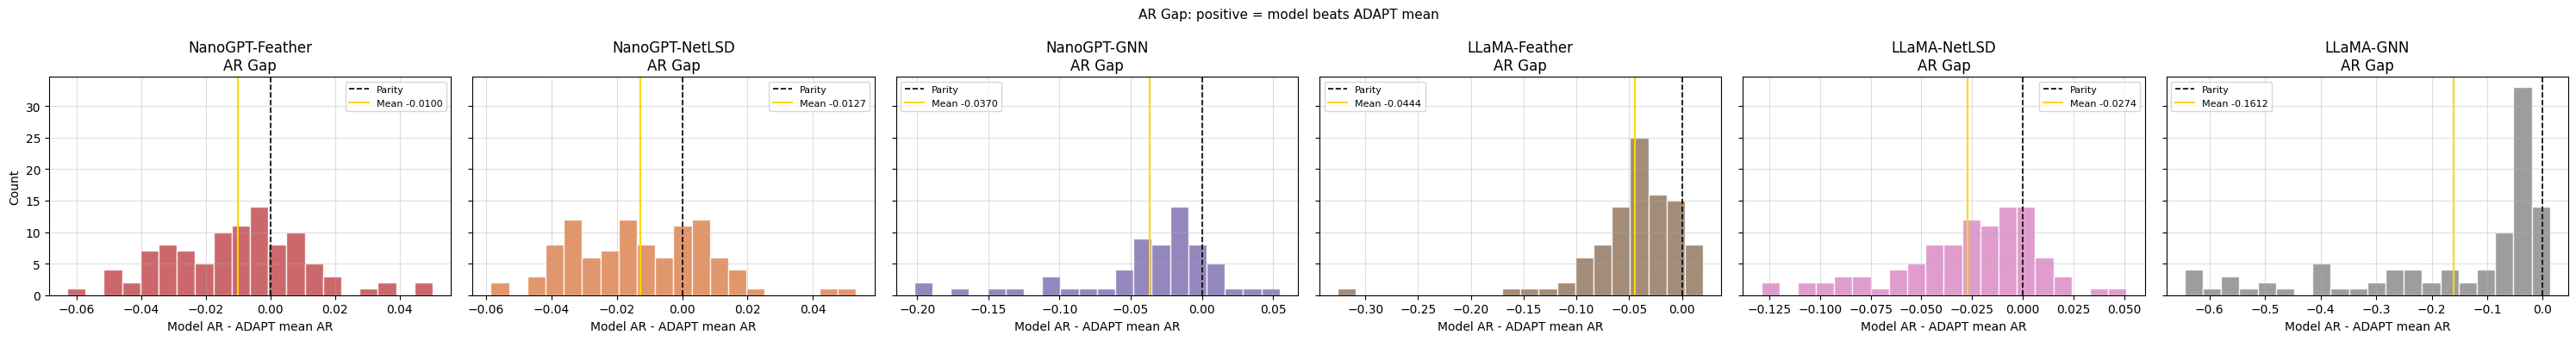

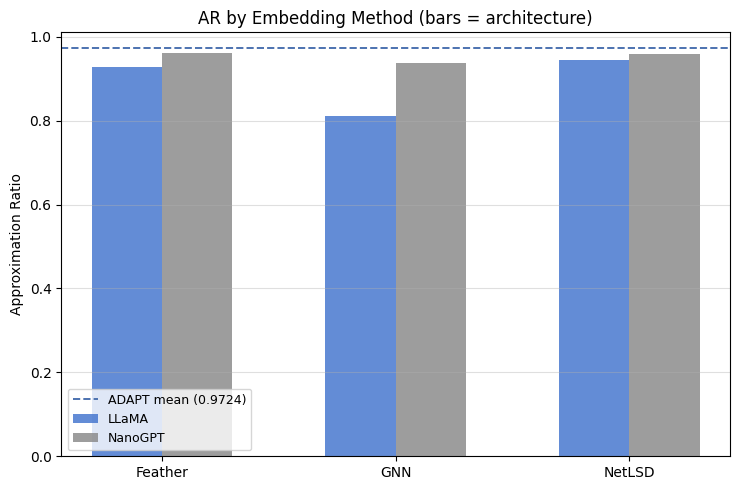

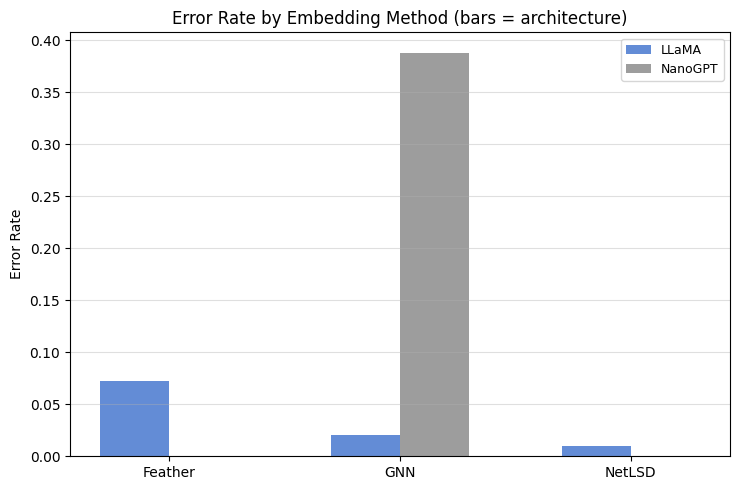

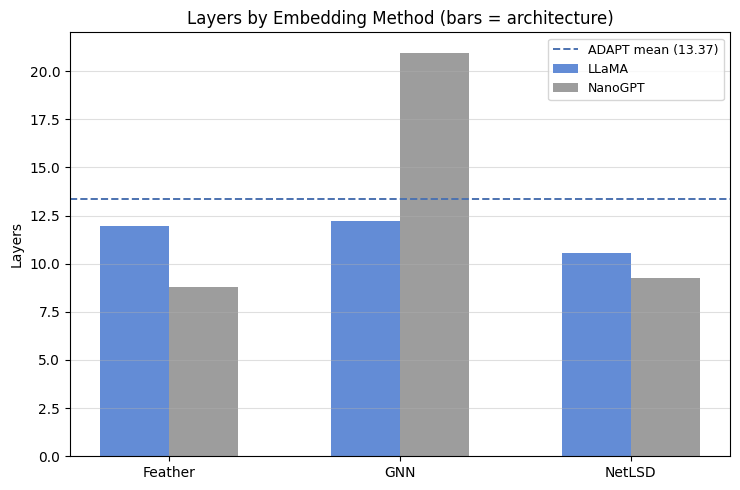

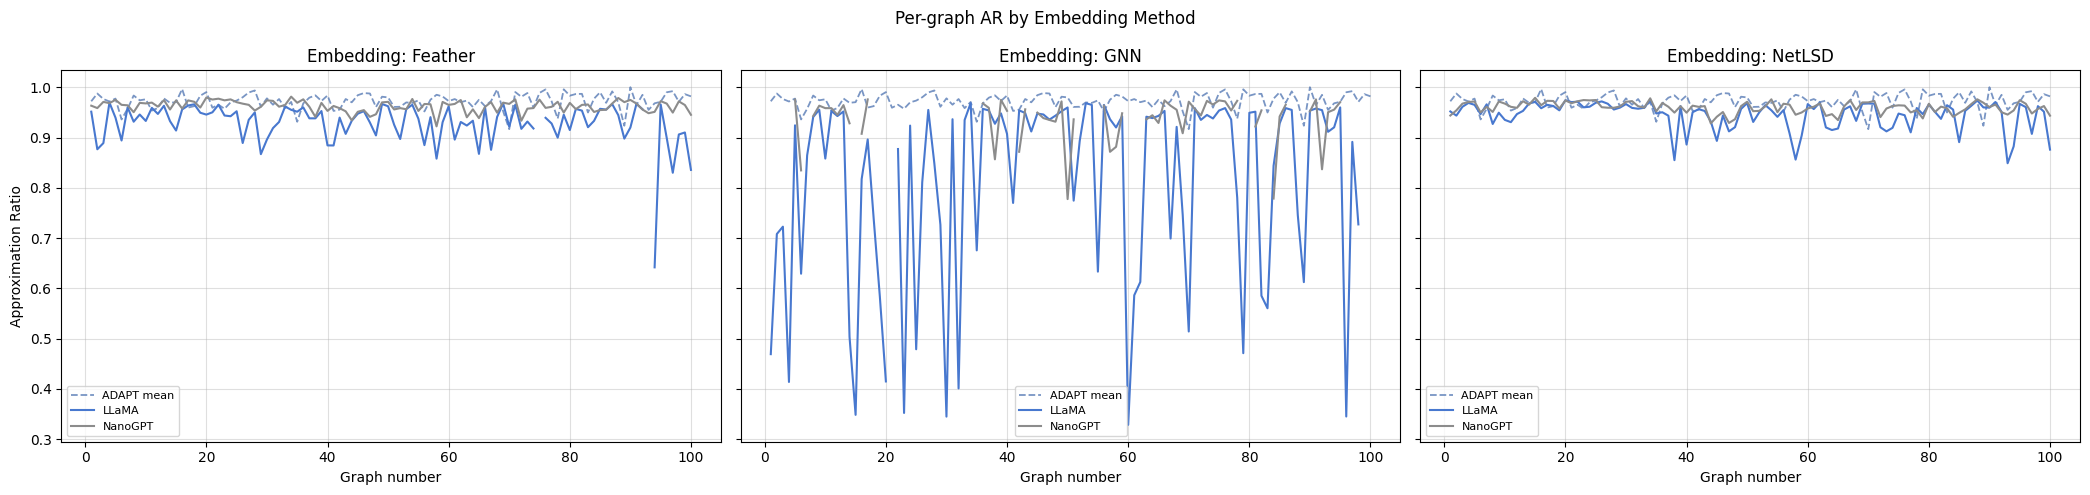

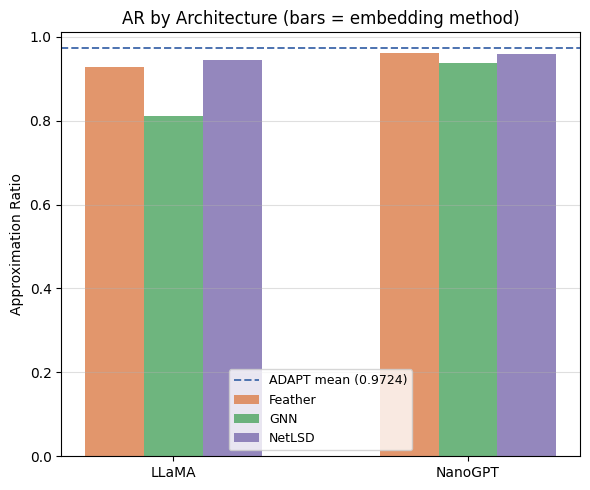

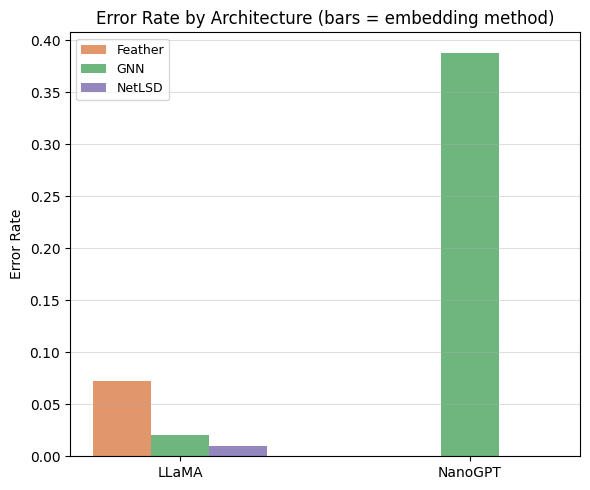

/tmp/ipykernel_5380/2456975394.py:86: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=archs, patch_artist=True, notch=False)


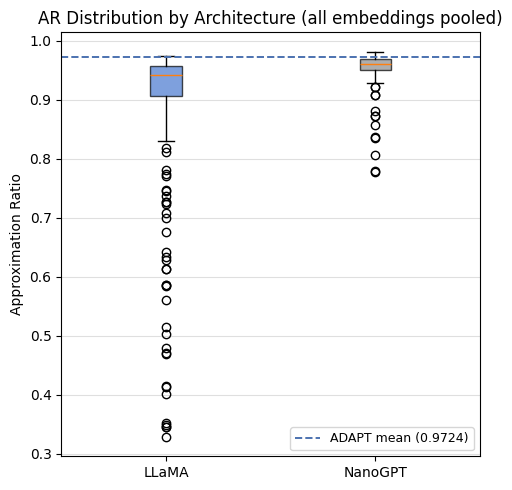

/tmp/ipykernel_5380/2456975394.py:112: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=methods, patch_artist=True, notch=False)


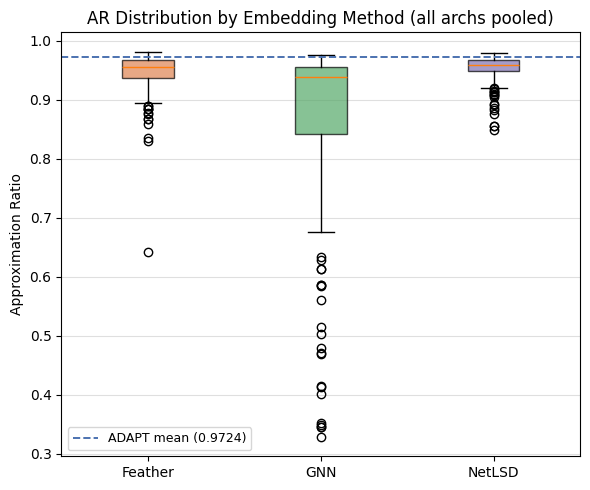

In [14]:
# ── Run all plots ──────────────────────────────────────────────────────────

# Section 1 — Overall
plot_ar_bar(summary_df)
plot_layers_bar(summary_df)
plot_error_rate_bar(summary_df)
plot_ar_vs_layers_scatter(final_df)
plot_per_graph_ar(final_df)
plot_ar_gap_hist(final_df)

# Section 2 — Embedding comparison
plot_ar_by_method(summary_df)
plot_error_rate_by_method(summary_df)
plot_layers_by_method(summary_df)
plot_per_graph_ar_by_method(final_df)

# Section 3 — Architecture comparison
plot_ar_by_arch(summary_df)
plot_error_rate_by_arch(summary_df)
plot_arch_ar_distribution(final_df)
plot_method_ar_distribution(final_df)

In [15]:
# ------------------------
# EXTRA INSIGHTS
# ------------------------

print("=" * 60)
print("INSIGHTS — per model")
print("=" * 60)

for _, row in summary_df.iterrows():
    print(f"\nModel : {row['model']}  (arch={row['arch']}, method={row['method']})")
    print(f"  Graphs evaluated      : {int(row['n_graphs'])}")
    print(f"  ADAPT AR (mean / best): {row['adapt_ar_mean']:.4f} / {row['adapt_ar_best']:.4f}")
    print(f"  Model AR              : {row['model_ar']:.4f}")
    print(f"  AR diff vs mean       : {row['ar_diff_vs_mean']:+.4f}")
    print(f"  AR diff vs best       : {row['ar_diff_vs_best']:+.4f}")
    print(f"  ADAPT layers (mean)   : {row['adapt_layers']:.2f}")
    print(f"  Model layers          : {row['model_layers']:.2f}")
    print(f"  Layer reduction       : {row['adapt_layers'] - row['model_layers']:+.2f}")
    print(f"  Model error rate      : {row['model_error_rate']:.4f}")

print("\n" + "=" * 60)
print("INSIGHTS — by architecture")
print("=" * 60)

for arch, grp in summary_df.groupby("arch"):
    print(f"\n  {arch}")
    print(f"    Mean AR              : {grp['model_ar'].mean():.4f}")
    print(f"    Mean error rate      : {grp['model_error_rate'].mean():.4f}")
    print(f"    Mean AR diff vs mean : {grp['ar_diff_vs_mean'].mean():+.4f}")

print("\n" + "=" * 60)
print("INSIGHTS — by embedding method")
print("=" * 60)

for method, grp in summary_df.groupby("method"):
    print(f"\n  {method}")
    print(f"    Mean AR              : {grp['model_ar'].mean():.4f}")
    print(f"    Mean error rate      : {grp['model_error_rate'].mean():.4f}")
    print(f"    Mean AR diff vs mean : {grp['ar_diff_vs_mean'].mean():+.4f}")

n_wins_mean = (final_df["ar_diff_vs_mean"] > 0).sum()
n_wins_best = (final_df["ar_diff_vs_best"] > 0).sum()
print(f"\n  Graphs where any model > ADAPT mean : {n_wins_mean} / {len(final_df)}")
print(f"  Graphs where any model > ADAPT best : {n_wins_best} / {len(final_df)}")

INSIGHTS — per model

Model : LLaMA-Feather  (arch=LLaMA, method=Feather)
  Graphs evaluated      : 100
  ADAPT AR (mean / best): 0.9724 / 0.9786
  Model AR              : 0.9280
  AR diff vs mean       : -0.0444
  AR diff vs best       : -0.0505
  ADAPT layers (mean)   : 13.37
  Model layers          : 11.98
  Layer reduction       : +1.39
  Model error rate      : 0.0720

Model : LLaMA-GNN  (arch=LLaMA, method=GNN)
  Graphs evaluated      : 100
  ADAPT AR (mean / best): 0.9724 / 0.9786
  Model AR              : 0.8112
  AR diff vs mean       : -0.1612
  AR diff vs best       : -0.1673
  ADAPT layers (mean)   : 13.37
  Model layers          : 12.23
  Layer reduction       : +1.14
  Model error rate      : 0.0200

Model : LLaMA-NetLSD  (arch=LLaMA, method=NetLSD)
  Graphs evaluated      : 100
  ADAPT AR (mean / best): 0.9724 / 0.9786
  Model AR              : 0.9450
  AR diff vs mean       : -0.0274
  AR diff vs best       : -0.0336
  ADAPT layers (mean)   : 13.37
  Model layers       